# Initial Setup & Getting Data
---

We can use the python package astroquery to download the data files for different objects in the sky. In this example, we find 6 months of data on the Crab Nebula

In [14]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import os
import requests

from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.time import Time

from astroquery.fermi import FermiLAT
from astroquery.heasarc import Heasarc
from astroquery.mast import Catalogs
import astropy.units as u

# Query System
---

In [ ]:
#Set the focus to the name of wherever your data files are saved (inside a folder called data).
#Plots will automatically be saved to a folder under the same name located in "images".
focus = "crab-6m"

#-------------------------------------------------------------#
#                      FermiLAT Query                         #
#-------------------------------------------------------------#

# query_object requires the name of the object, the energy range, and the dates ov observation.
result = FermiLAT.query_object('Crab', energyrange_MeV='100, 300000', obsdates='2019-01-01 00:00:00, 2019-06-01 00:00:00')

os.makedirs(f"data/{focus}", exist_ok=True)
os.makedirs(f"images/{focus}", exist_ok=True)

for url in result:
    raw = url.split("/")[-1]
    filename = raw.split("_", 1)[1]
    print("Downloading:", filename)
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(f"data/{focus}/{filename}", "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

print("FermiLAT download complete.")

#-------------------------------------------------------------#
#              Gamma-Ray Burst Monitor Query                  #
#-------------------------------------------------------------#
'''
heasarc = Heasarc()

gbm_result = heasarc.query_region(
    "Crab",
    mission="fermigtrig",
    radius="15 deg"
)

for row in gbm_result:
    
    # trigger ID column (may vary slightly depending on catalog version)
    trig_id = row["TRIGGER_ID"]
    
    base_url = f"https://heasarc.gsfc.nasa.gov/FTP/fermi/data/gbm/triggers/{trig_id}/current/"
    
    print("Processing trigger:", trig_id)

    # common GBM files (not all triggers will have all of these)
    files = [
        "glg_tte_b0.fit",
        "glg_cspec_b0.fit"
    ]

    for fname in files:
        url = base_url + fname
        
        try:
            r = requests.get(url, stream=True)
            r.raise_for_status()
            outpath = f"data/{focus}/gbm/{trig_id}_{fname}"
            with open(outpath, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)

            print("Downloaded:", outpath)

        except Exception:
            print("Missing:", url)

print("GBM download complete.")

'''

#-------------------------------------------------------------#
#                          JWST Query                         #
#-------------------------------------------------------------#
'''
target_name = "Crab Nebula"

obs = Observations.query_object(target_name, radius="0.2 deg")
jwst_obs = obs[obs["obs_collection"] == "JWST"]

print(f"Total JWST observations: {len(jwst_obs)}")


products = Observations.get_product_list(jwst_obs)

products = Observations.filter_products(
    products,
    productType="SCIENCE",
    extension="fits"
)
manifest = Observations.download_products(
    products,
    download_dir="data/jwst",
    mrp_only=False
)
print("JWST download complete.")
'''


Downloading: PH00.fits
Downloading: SC00.fits
Done.


# Extract Data
---

In [4]:
#Extracting information
energies = []
ras = []
decs = []
times = []

i = 0
while True:
    filename = f"data/{focus}/PH{str(i).zfill(2)}.fits"
    
    if not os.path.exists(filename):
        print(f"Stopped at: {filename} (file not found)")
        break

    print(f"Reading: {filename}")

    hdul = fits.open(filename)
    data = hdul[1].data

    energies.extend(data["ENERGY"])
    ras.extend(data["RA"])
    decs.extend(data["DEC"])
    times.extend(data["TIME"])

    hdul.close()
    i += 1

energies = np.array(energies)
ras = np.array(ras)
decs = np.array(decs)
times = np.array(times)

print("number of data points:", len(energies))


Reading: data/crab-6m/PH00.fits
Stopped at: data/crab-6m/PH01.fits (file not found)
number of data points: 413314


# Making Some Basic Plots
---

Here are a few simple plots so we can see what we are working with.

The energy histogram of the energy spectrum shows us that there are more lower-energy photons than higher energy photons.  
But, keep in mind that FermiLAT detects between 20 MeV to ~300 GeV, so even the lowest energy photons on this plot, near 0 are still at least 20 MeV gamma rays.

To visualize what we are really looking at, we want to plot the gamma rays in such a way so that we can see areas of higher and lower density.  
We do this by binning them into a 2D histogram where the color shows the count within each histogram bin. This allows us to see the density of gamma ray per sky section. 


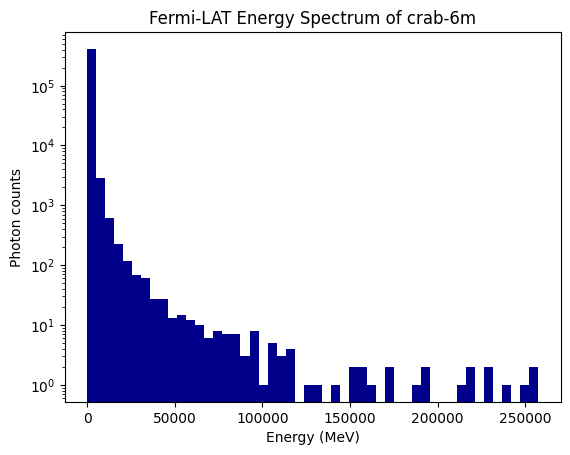

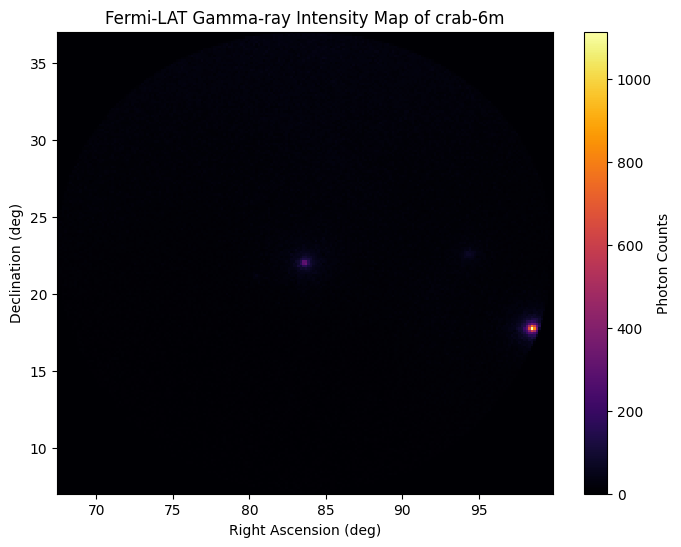

In [5]:
#Histogram of the Energy Spectrum
plt.hist(energies, bins=50, log=True,color='darkblue')
plt.xlabel("Energy (MeV)")
plt.ylabel("Photon counts")
plt.title(f"Fermi-LAT Energy Spectrum of {focus}")
plt.savefig(f"images/{focus}/energy_spectrum.png", dpi=300)
plt.show()

#Heatmap of Gamma Rays (2D Histogram)
plt.figure(figsize=(8,6))
counts, xedges, yedges, img = plt.hist2d(ras,decs,bins=200,cmap='inferno')
plt.colorbar(label="Photon Counts")
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title(f"Fermi-LAT Gamma-ray Intensity Map of {focus}")
plt.savefig(f"images/{focus}/GR_intensity_map.png", dpi=300)
plt.show()

### Zooming In on the Heatmap:  

We cannot really see much detail, so lets zoom in, and then smooth out the histogram using a gaussian blur to make a nicer image!  
Look at the attached image of the crab nebula. Can you see the similarities in the images? 

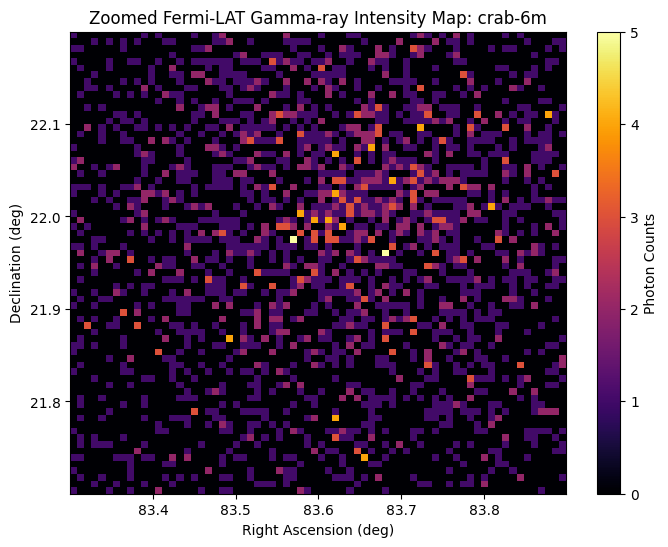

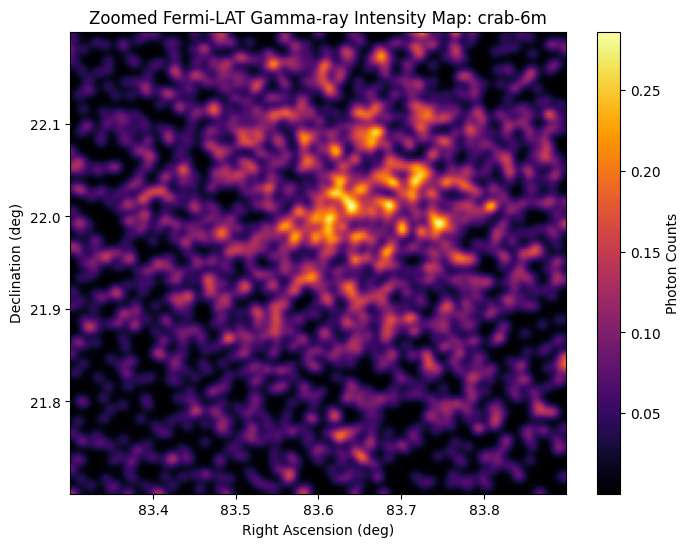

In [6]:
#Filter for Zooming (change as needed for whatever object you are viewing)
mask = (decs >= 21.7) & (decs <= 22.2) & (ras >= 83.3) & (ras <= 83.9)
ras_zoom = ras[mask]
decs_zoom = decs[mask]

#Zoomed Heatmap of Gamma Rays (2D Histogram)
plt.figure(figsize=(8,6))
counts, xedges, yedges, img = plt.hist2d(ras_zoom,decs_zoom,bins=70,cmap='inferno')
plt.colorbar(label="Photon Counts")
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title(f"Zoomed Fermi-LAT Gamma-ray Intensity Map: {focus}")
plt.savefig(f"images/{focus}/zoom_heatmap.png", dpi=300)
plt.show()

#Use Gaussian Blur to Smooth the Zoomed Heatmap
plt.figure(figsize=(8,6))
counts, xedges, yedges = np.histogram2d(ras_zoom, decs_zoom, bins=200)
counts_smooth = gaussian_filter(counts, sigma=2)
img = plt.imshow(
    counts_smooth.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='inferno',
    aspect='auto'
)
plt.colorbar(img, label="Photon Counts")
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title(f"Zoomed Fermi-LAT Gamma-ray Intensity Map: {focus}")
plt.savefig(f"images/{focus}/zoom_heatmap.png", dpi=300)
plt.show()

# Light Curves
---

Lets plot the number of events recorded per amount of time!

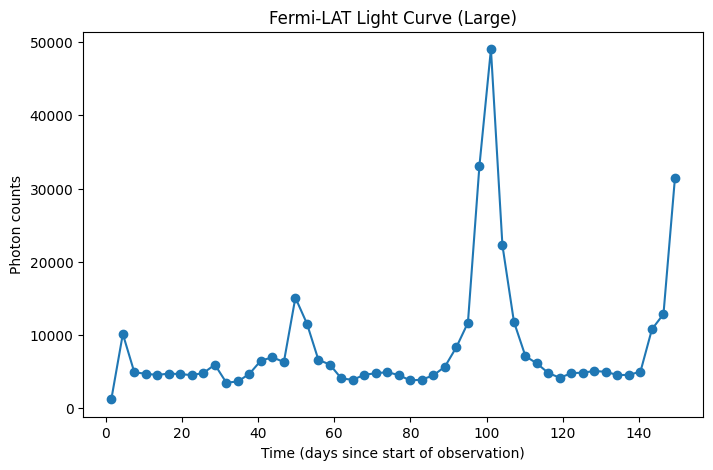

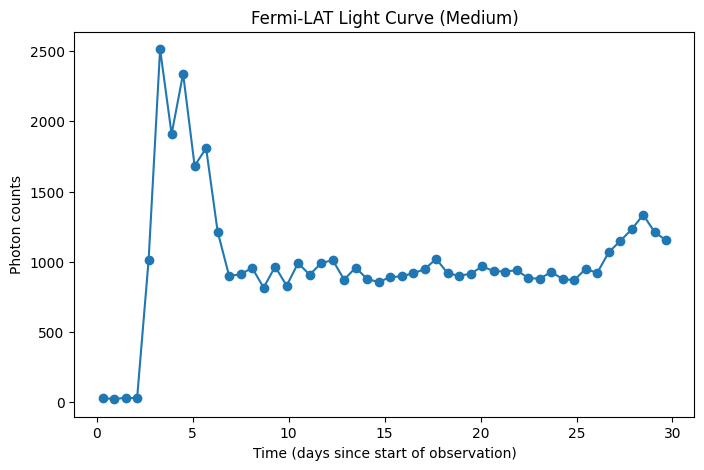

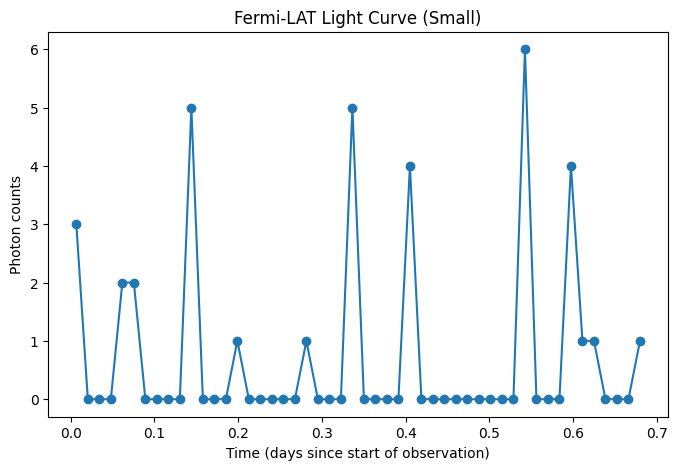

In [11]:
# Define light curve plot function
def make_lightcurve(times_days, duration_days, bins, label, filename):
    time_mask = times_days <= duration_days
    subset = times_days[time_mask]

    counts, edges = np.histogram(subset, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2

    plt.figure(figsize=(8,5))
    plt.plot(centers, counts, marker="o")
    plt.xlabel("Time (days since start of observation)")
    plt.ylabel("Photon counts")
    plt.title(f"Fermi-LAT Light Curve ({label})")
    plt.savefig(filename, dpi=300)
    plt.show()


#Durations in days
times_days = (times - times.min()) / 86400
large = 365
medium = 30
small = 1

# Make 3 light curves for the different durations
make_lightcurve(times_days, large, 50, "Large",f"images/{focus}/LT_curve_large.png")
make_lightcurve(times_days, medium, 50, "Medium",f"images/{focus}/LT_curve_medium.png")
make_lightcurve(times_days, small, 50, "Small",f"images/{focus}/LT_curve_small.png")

# Fitting Gaussian to the periodicity of the Year Long Light Curve

Notice how the 1 Year Light Curve seems to periodically have peaks? Lets fit gaussians to the peaks and see how far apart they are in days.  
Note that the precession period of the Fermi spacecraft is 53.4 days...   

(Source: https://fermi.gsfc.nasa.gov/ssc/data/analysis/LAT_caveats_temporal.html)

/tmp/ipykernel_1997772/2190730932.py:33: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(gaussian, x_fit, y_fit, p0=p0)


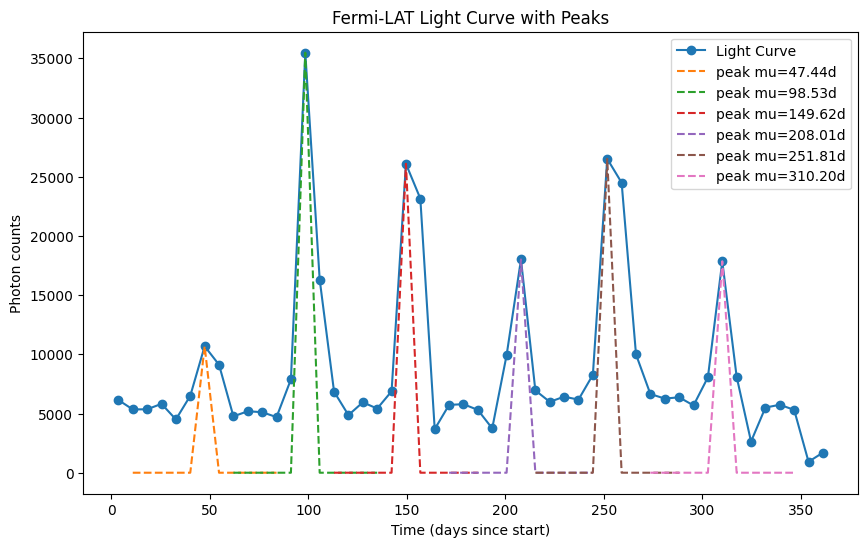

peaks located at (days): [ 47.44175515  98.53287608 149.62399701 208.0138495  251.80623887
 310.19609136]

time between each peak (days): [51.09112093 51.09112093 58.38985249 43.79238937 58.38985249]

average time between peaks (days): 52.55086724246581



In [52]:
# Bin light curve
times_days = (times - times.min()) / 86400
bins = 50
counts, edges = np.histogram(times_days, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(10,6))
plt.plot(centers, counts, marker='o', label="Light Curve")

# Define Gaussian function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5*((x-mu)/sigma)**2)

# Detect peaks (force 6 peaks)
peak_indices, _ = find_peaks(counts, height=np.mean(counts), distance=5)
if len(peak_indices) > 6:
    peak_indices = peak_indices[:6]  # keep first 6 largest peaks

sigma_list = []
mu_list = []

# Fit a Gaussian locally around each peak
window = 5  # number of bins on each side of peak to fit
for idx in peak_indices:
    # select local region
    left = max(idx-window,0)
    right = min(idx+window,len(counts)-1)
    x_fit = centers[left:right+1]
    y_fit = counts[left:right+1]

    p0 = [counts[idx], centers[idx], 0.1]  # initial guess
    try:
        popt, _ = curve_fit(gaussian, x_fit, y_fit, p0=p0)
        A_fit, mu_fit, sigma_fit = popt
        sigma_list.append(sigma_fit)
        mu_list.append(mu_fit)
        plt.plot(x_fit, gaussian(x_fit, *popt), '--', label=f'peak mu={mu_fit:.2f}d')
    except RuntimeError:
        print(f"Failed to fit peak at index {idx}")

# Compute time differences between consecutive Gaussian centers
mu_list = np.array(mu_list)
periods = np.diff(np.sort(mu_list))


plt.xlabel("Time (days since start)")
plt.ylabel("Photon counts")
plt.title("Fermi-LAT Light Curve with Peaks")
plt.legend()
plt.savefig(f"images/{focus}/light_curve_peaks.png", dpi=300)
plt.show()

print(f"peaks located at (days): {mu_list}\n")
print(f"time between each peak (days): {periods}\n")
print(f"average time between peaks (days): {np.mean(periods)}\n")

So the peaks match up with the precessional period of the Fermi Spacecraft! Cool!